Download dataset

In [114]:
import kagglehub

path = kagglehub.dataset_download("xseeker0/translation-from-classi"
                                  "cal-chinese-to-english", output_dir="./data")

Read Dataset

In [115]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "weyan_idioms.csv"))
df.head()  # Show first five rows

,zh,en
0,乾统三年，徙封秦国。,"In the third year of the Qingtong Era, he was ..."
1,莽曰监邛。,It was called Jianggongsu in Wang Mang's time.
2,辛未，以复置尚书省诏天下。,"On the tenth day of the first lunar month, an ..."
3,《司马法》广陈三代，曰：古者六尺为步，步百为亩，亩百为夫，夫三为屋，屋三为井。,The Book of Sima's Military Methods extensivel...
4,事平，加特进、右骁卫大将军，弘志右卫上将军兼中尉，守义右领军卫上将军。,"After the incident had ended, Qiu Shiliang was..."


#### Tokenize

|   |English| Chinese  |
|---|:------|:----|
| 1 |Convert to lowercase| \   |
| 2 |Add spaces before punctuation marks| \  |
|3|Seperate by space| Seperate by character |

In [116]:
import re


def tokenize_en(text: str) -> list[str]:
    basic = r"\S\w*"  # basic case
    hyphen = r"\w+(?:[-']\w+)*"  # handle hyphen: "pre-train"
    point = r"(?:\w+\.)+\w+(?:\.)*"  # handle point: "U.S.A"
    pattern = point + r"|" + hyphen + r"|" + basic
    return re.findall(pattern, text.lower())


def tokenize_zh(text: str) -> list[str]:
    return [char for char in text if not char.isspace()]


# Replace NaN with empty string
df['en'] = df['en'].fillna("")
df['zh'] = df['zh'].fillna("")

# Tokenize
df['en_tokens'] = df['en'].apply(tokenize_en)
df['zh_tokens'] = df['zh'].apply(tokenize_zh)

Tokenize result

In [117]:
df[['zh', 'zh_tokens']].head()

,zh,zh_tokens
0,乾统三年，徙封秦国。,"[乾, 统, 三, 年, ，, 徙, 封, 秦, 国, 。]"
1,莽曰监邛。,"[莽, 曰, 监, 邛, 。]"
2,辛未，以复置尚书省诏天下。,"[辛, 未, ，, 以, 复, 置, 尚, 书, 省, 诏, 天, 下, 。]"
3,《司马法》广陈三代，曰：古者六尺为步，步百为亩，亩百为夫，夫三为屋，屋三为井。,"[《, 司, 马, 法, 》, 广, 陈, 三, 代, ，, 曰, ：, 古, 者, 六, ..."
4,事平，加特进、右骁卫大将军，弘志右卫上将军兼中尉，守义右领军卫上将军。,"[事, 平, ，, 加, 特, 进, 、, 右, 骁, 卫, 大, 将, 军, ，, 弘, ..."


In [118]:
df[['en', 'en_tokens']].head()

,en,en_tokens
0,"In the third year of the Qingtong Era, he was ...","[in, the, third, year, of, the, qingtong, era,..."
1,It was called Jianggongsu in Wang Mang's time.,"[it, was, called, jianggongsu, in, wang, mang'..."
2,"On the tenth day of the first lunar month, an ...","[on, the, tenth, day, of, the, first, lunar, m..."
3,The Book of Sima's Military Methods extensivel...,"[the, book, of, sima's, military, methods, ext..."
4,"After the incident had ended, Qiu Shiliang was...","[after, the, incident, had, ended, ,, qiu, shi..."


#### Vocabulary

In [135]:
from collections import Counter

# get all words
words_en = df['en_tokens'].explode().dropna().tolist()
words_zh = df['zh_tokens'].explode().dropna().tolist()

# Special tokens
PAD_TOKEN = "<PAD>"  # padding
UNK_TOKEN = "<UNK>"  # unknown
BOS_TOKEN = "<BOS>"  # beginning of sentence
EOS_TOKEN = "<EOS>"  # end of sentence


class Vocabulary:
    # Use Counter to get vocabulary
    def __get_counter(self, words: list[str], min_freq=0) -> Counter:
        # count raw frequency
        raw_counts = Counter(words)
        # remove low frequency words
        filtered_words = [
            word for word, freq in raw_counts.items()
            if freq >= min_freq and word not in [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]
        ]
        # add special tokens
        return Counter([PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN] + filtered_words)

    def __init__(self, words: list[str], min_freq=0):
        self.__counter = self.__get_counter(words, min_freq)
        self.__str_to_idx = {token: idx for idx, token in enumerate(self.__counter.keys())}

    def __len__(self):
        return len(self.__counter)

    def numericalize(self, sentence: list[str]):
        # if token not in vocabulary, use UNK_TOKEN
        return [self.__str_to_idx.get(token, UNK_TOKEN) for token in sentence]


min_frequency = 0
vocabulary_en = Vocabulary(words_en, min_frequency)
vocabulary_zh = Vocabulary(words_zh, min_frequency)

Result

In [140]:
pd.concat([df['en'].head(5),
           df['en_tokens'].head(5).apply(vocabulary_en.numericalize)],
          axis=1)

,en,en_tokens
0,"In the third year of the Qingtong Era, he was ...","[4, 5, 6, 7, 8, 5, 9, 10, 11, 12, 13, 14, 15, ..."
1,It was called Jianggongsu in Wang Mang's time.,"[20, 13, 21, 22, 4, 23, 24, 25, 19]"
2,"On the tenth day of the first lunar month, an ...","[26, 5, 27, 28, 8, 5, 29, 30, 31, 11, 32, 33, ..."
3,The Book of Sima's Military Methods extensivel...,"[5, 41, 8, 42, 43, 44, 45, 46, 5, 47, 8, 5, 48..."
4,"After the incident had ended, Qiu Shiliang was...","[75, 5, 76, 77, 78, 11, 79, 80, 13, 81, 15, 82..."


In [141]:
print('\nTotal number of tokens:')
print('zh:', len(vocabulary_zh))
print('en:', len(vocabulary_en))


Total number of tokens:
zh: 12065
en: 179135


#### Dataset

In [156]:
from torch.utils.data import Dataset, DataLoader
import torch


class TranslationDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, vocab_en: Counter, vocab_zh: Counter):
        self.dataframe = dataframe
        self.vocab_en = vocab_en
        self.vocab_zh = vocab_zh

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get sentence and add special tokens
        en_sentence = [BOS_TOKEN] + self.dataframe.iloc[index]['en_tokens'] + [EOS_TOKEN]
        zh_sentence = [BOS_TOKEN] + self.dataframe.iloc[index]['zh_tokens'] + [EOS_TOKEN]

        # Convert to indices
        en_sentence = vocabulary_en.numericalize(en_sentence)
        zh_sentence = vocabulary_zh.numericalize(zh_sentence)

        # Convert to tensors
        return torch.tensor(en_sentence), torch.tensor(zh_sentence)

#### Position encoding

According to the [**paper**](https://arxiv.org/pdf/1706.03762), the position encoding is defined as follows:

$$
\begin{aligned}
PE_{(pos,2i)} = sin(pos / 10000^{2i/ d_{model}}) \\
PE_{(pos,2i+1)} = cos(pos / 10000^{2i/ d_{model}})
\end{aligned}
$$

where $pos$ is the position of the token in the sequence and $i$ is the index along the embedding dimension ($d_{model}$)

Here we use NumPy to generate the position encoding matrix and convert it to a Torch tensor
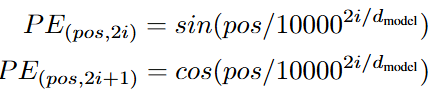

In [143]:
import numpy as np


def get_position_encoding_matrix(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    # pos
    position = np.arange(0, max_len)[:, np.newaxis]  # [max_len, 1]

    # 10000^(2i/d_model)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # calculate by broadcasting
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    # convert to tensor
    return pe

Result (heat map)

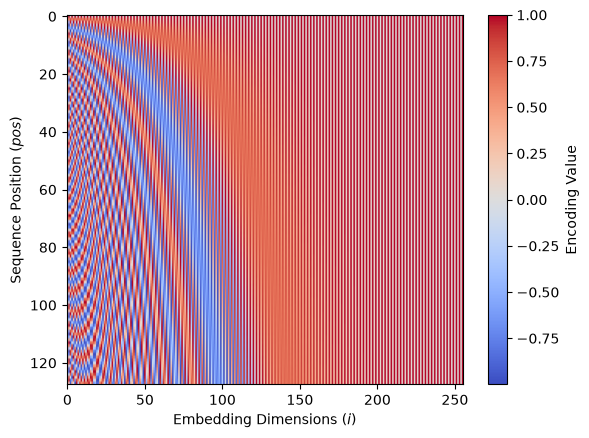

In [144]:
import matplotlib.pyplot as plt

pe_matrix = get_position_encoding_matrix(128, 256)

plt.imshow(pe_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Encoding Value')
plt.xlabel("Embedding Dimensions ($i$)")
plt.ylabel("Sequence Position ($pos$)")

plt.show()

#### Transformer Model
Encoder

In [ ]:
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_layers, heads, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)



Decoder

#### Training

#### Result

#### Reference
[Attention Is All You Need](https://arxiv.org/pdf/1706.03762.pdf)